In [1]:
import logging
import numpy as np
import snapatac2 as snap

from collections import defaultdict
from matplotlib import pyplot as plt

logging.basicConfig(filename="/Users/emattei/Tmp/test_snapatac/snap_stats.txt", level=logging.INFO)

chrom_sizes="/Users/emattei/Annotations/HG38/GRCh38_EBV.chrom.sizes.no.alt.tsv"
chrom_sizes_dict = defaultdict(int)


with open(chrom_sizes, "r") as fh:
    for line in fh:
        chrom_sizes_dict[line.strip().split("\t")[0]] = int(line.strip().split("\t")[1])

In [2]:
chrom_sizes_dict

defaultdict(int,
            {'chr1': 248956422,
             'chr2': 242193529,
             'chr3': 198295559,
             'chr4': 190214555,
             'chr5': 181538259,
             'chr6': 170805979,
             'chr7': 159345973,
             'chr8': 145138636,
             'chr9': 138394717,
             'chr10': 133797422,
             'chr11': 135086622,
             'chr12': 133275309,
             'chr13': 114364328,
             'chr14': 107043718,
             'chr15': 101991189,
             'chr16': 90338345,
             'chr17': 83257441,
             'chr18': 80373285,
             'chr19': 58617616,
             'chr20': 64444167,
             'chr21': 46709983,
             'chr22': 50818468,
             'chrX': 156040895,
             'chrY': 57227415,
             'chrM': 16569})

In [ ]:
data = snap.pp.import_data(
        fragment_file="/Users/emattei/Tmp/chromap/000",
        chrom_sizes=chrom_sizes_dict,
        sorted_by_barcode=True,
        min_num_fragments=500,
        shift_left=4,
        shift_right=-4
    )

In [ ]:
# Unique barcodes with more than 10 fragments
logging.info(data.shape[0])

NameError: name 'data' is not defined

In [29]:
snap.metrics.tsse(data, "/Users/emattei/Annotations/HG38/genes.gtf.gz")

In [6]:
data

AnnData object with n_obs × n_vars = 76033 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [21]:
snap.pl.frag_size_distr(data, max_recorded_size=1000, show=False)
data

2024-10-30 15:21:04 - INFO - Computing fragment size distribution...


AnnData object with n_obs × n_vars = 76033 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences', 'frag_size_distr'
    obsm: 'fragment_paired'

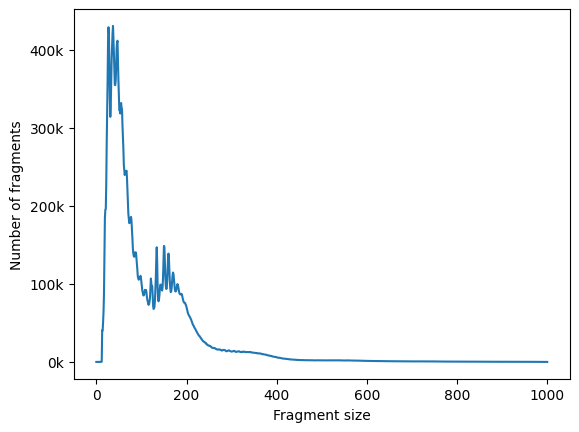

In [8]:
from matplotlib.ticker import FuncFormatter

def thousands_formatter(x, pos):
    return '%1.0fk' % (x * 1e-3)

plt.plot(data.uns['frag_size_distr'])
plt.xlabel("Fragment size")
plt.ylabel("Number of fragments")
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
plt.savefig("/Users/emattei/Tmp/test_snapatac/fragment_size_distribution.png")
plt.show()

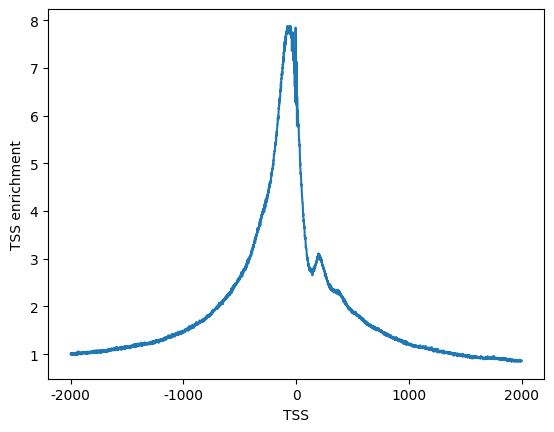

In [9]:
plt.plot(data.uns['TSS_profile']/data.uns['TSS_profile'][0])
plt.xlabel("TSS")
plt.ylabel("TSS enrichment")
plt.xticks(ticks=[0, 1000, 2000, 3000, 4000], labels=['-2000', '-1000', '0', '1000', '2000'])
plt.savefig("/Users/emattei/Tmp/test_snapatac/TSS_enrichment.png")
plt.show()

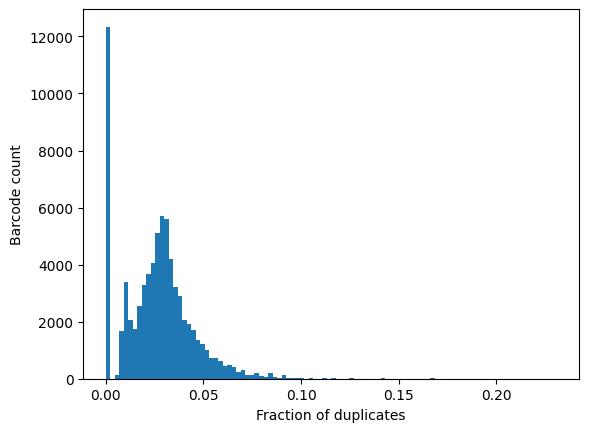

In [23]:
plt.hist(data.obs['frac_dup'], bins=100)
plt.xlabel("Fraction of duplicates")
plt.ylabel("Barcode count")
plt.savefig("/Users/emattei/Tmp/test_snapatac/fraction_duplicates_distribution.png")
plt.show()

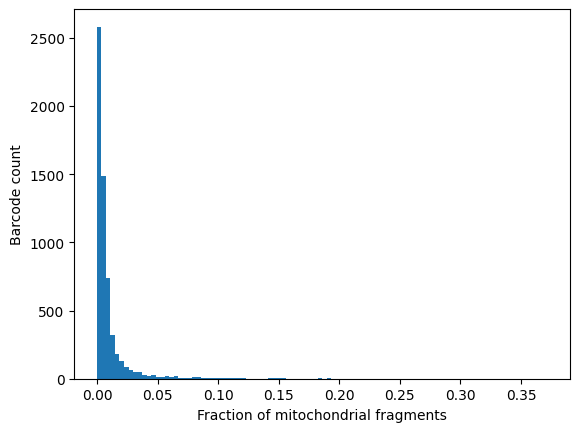

In [127]:
plt.hist(data.obs['frac_mito'], bins=100)
plt.xlabel("Fraction of mitochondrial fragments")
plt.ylabel("Barcode count")
plt.savefig("/Users/emattei/Tmp/test_snapatac/fraction_mito_distribution.png")
plt.show()

In [11]:
with open("/Users/emattei/Tmp/test_snapatac/frac_overlap_TSS.txt","w") as fh:
    fh.write(f"{data.uns['frac_overlap_TSS']:.2f}")


In [12]:
with open("/Users/emattei/Tmp/test_snapatac/library_TSSe.txt","w") as fh:
    fh.write(f"{data.uns['library_tsse']:.2f}")

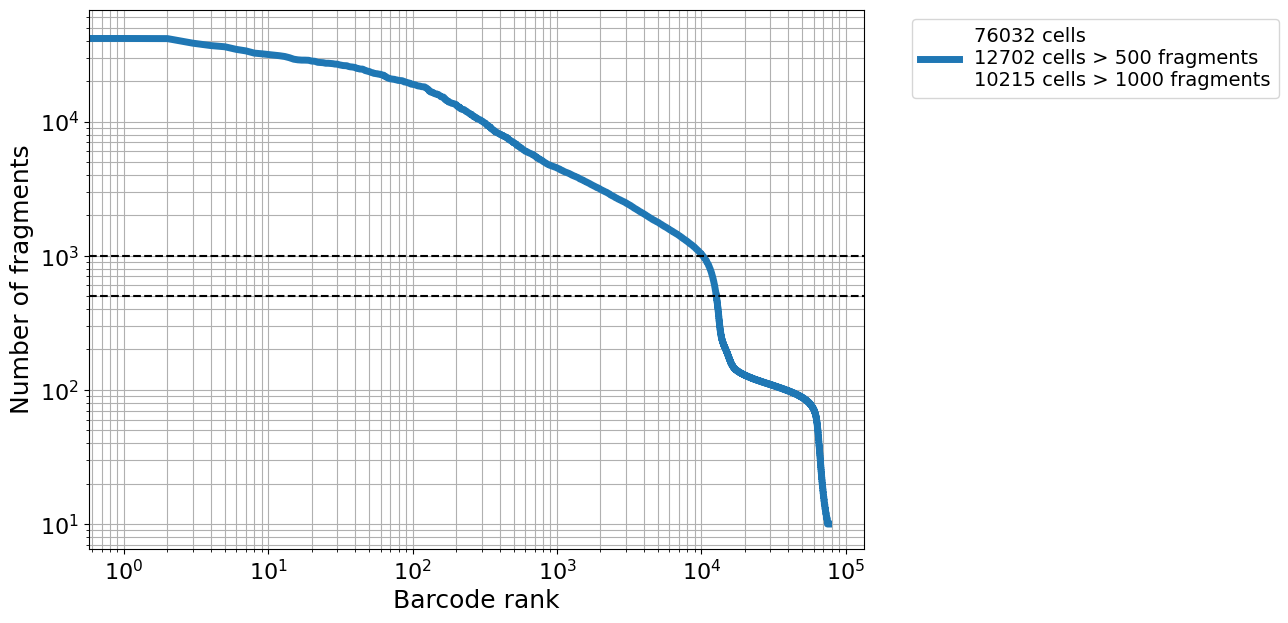

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
knee = np.sort((np.array(data.obs['n_fragment']))) [::-1]
cell_set = np.arange(len(knee))
num_cells = cell_set[::-1][0]

# Calculate the number of cells with more than 500 fragments
num_cells_above_500 = np.sum(knee > 500)
num_cells_above_1000 = np.sum(knee > 1000)

# plot the knee for the current sublibrary
ax.loglog(cell_set, knee, linewidth=5, label=f"{num_cells} cells\n{num_cells_above_500} cells > 500 fragments\n{num_cells_above_1000} cells > 1000 fragments")

ax.axhline(y=500, linewidth=1.5, color="k", linestyle='--')
ax.axhline(y=1000, linewidth=1.5, color="k", linestyle='--')

ax.set_ylabel("Number of fragments", fontsize=18)
ax.set_xlabel("Barcode rank",fontsize=18)
ax.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')

ax.tick_params(axis='both', which='major', labelsize=16)

plt.grid(True, which="both")
plt.savefig("/Users/emattei/Tmp/test_snapatac/Barcode_rank_plot.png", bbox_inches='tight')

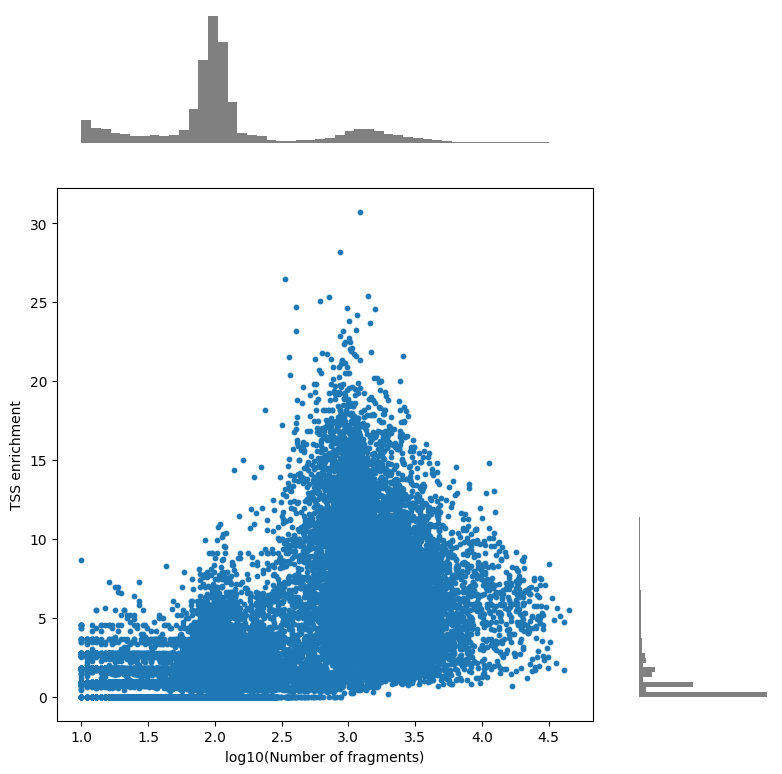

In [14]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(3, 3, width_ratios=[4, 1, 0.1], height_ratios=[1, 4, 0.1])

ax_main = plt.subplot(gs[1, 0])
ax_top = plt.subplot(gs[0, 0], sharex=ax_main)
ax_right = plt.subplot(gs[1, 1], sharey=ax_main)

# Main scatter plot
ax_main.scatter(np.log10(data.obs['n_fragment']), data.obs['tsse'], s=10)
ax_main.set_xlabel('log10(Number of fragments)')
ax_main.set_ylabel('TSS enrichment')

# Top histogram
ax_top.hist(np.log10(data.obs['n_fragment']), bins=50, color='gray')
ax_top.axis('off')

# Right histogram
ax_right.hist(data.obs['tsse'], bins=100, orientation='horizontal', color='gray')
ax_right.axis('off')

#plt.tight_layout()
plt.show()


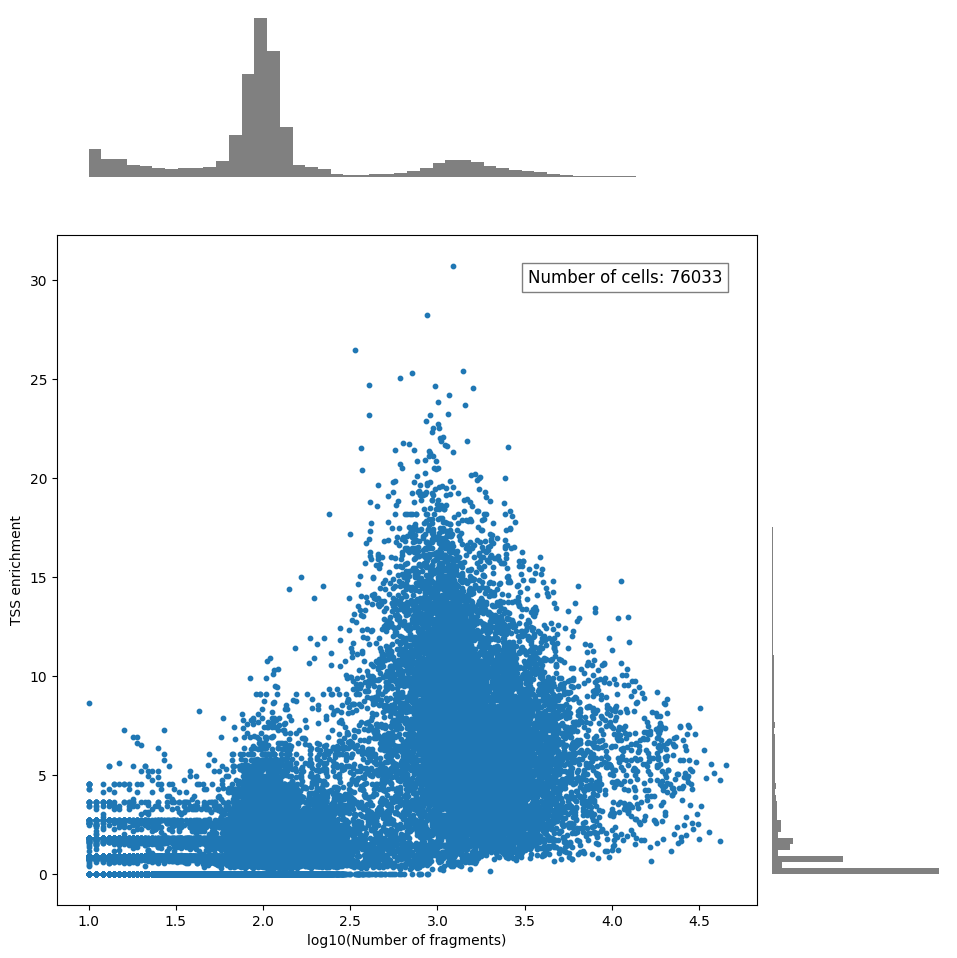

In [15]:
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(3, 3, width_ratios=[4, 1, 0.1], height_ratios=[1, 4, 0.1])

ax_main = plt.subplot(gs[1, 0])
ax_top = plt.subplot(gs[0, 0], sharex=ax_main)
ax_right = plt.subplot(gs[1, 1], sharey=ax_main)

# Main scatter plot
ax_main.scatter(np.log10(data.obs['n_fragment']), data.obs['tsse'], s=10)
ax_main.set_xlabel('log10(Number of fragments)')
ax_main.set_ylabel('TSS enrichment')

# Add the number of cells in the upper right corner
num_cells = data.obs['n_fragment'].shape[0]
ax_main.text(0.95, 0.95, f'Number of cells: {num_cells}', transform=ax_main.transAxes, 
             verticalalignment='top', horizontalalignment='right', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Top histogram
ax_top.hist(np.log10(data.obs['n_fragment']), bins=50, color='gray')
ax_top.axis('off')

# Right histogram
ax_right.hist(data.obs['tsse'], bins=100, orientation='horizontal', color='gray')
ax_right.axis('off')

plt.tight_layout()
plt.savefig("/Users/emattei/Tmp/test_snapatac/fragments_vs_tsse.png", bbox_inches='tight')
plt.show()

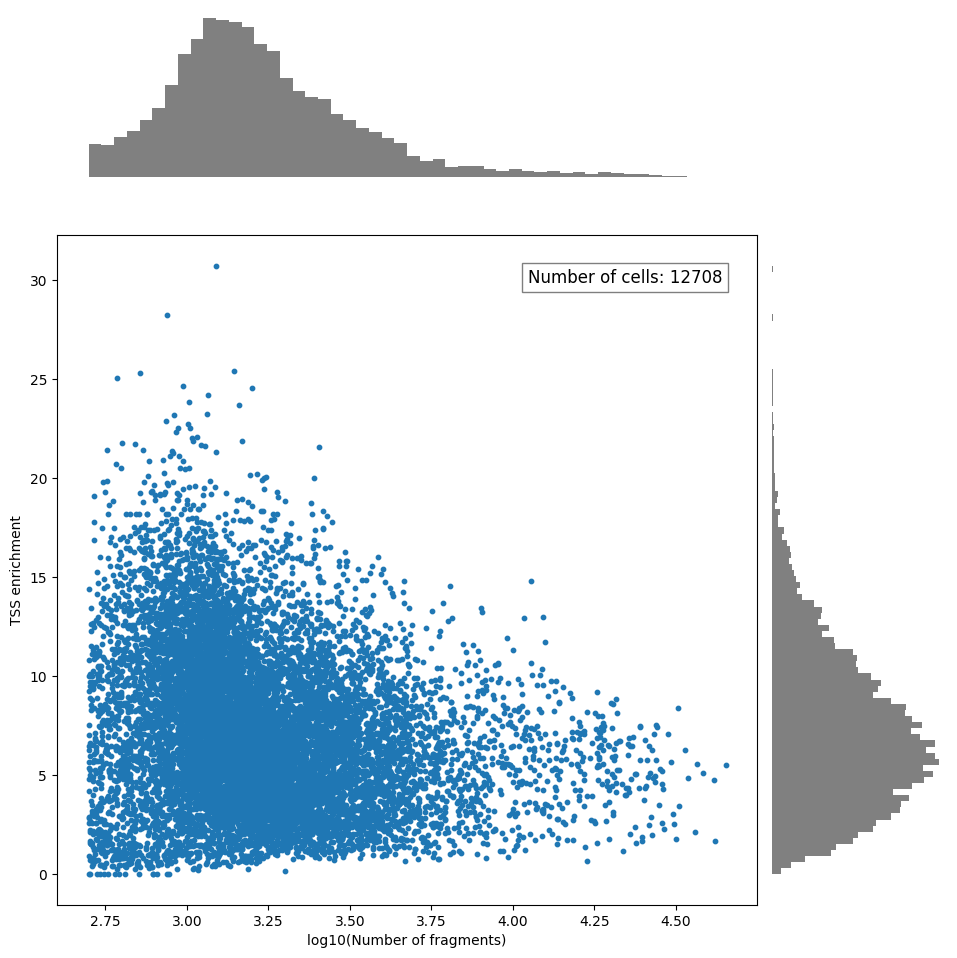

In [16]:
# Filter the data to keep only barcodes with 500 or more fragments
filtered_data = data[data.obs['n_fragment'] >= 500]

# Update the plots to use the filtered data
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(3, 3, width_ratios=[4, 1, 0.1], height_ratios=[1, 4, 0.1])

ax_main = plt.subplot(gs[1, 0])
ax_top = plt.subplot(gs[0, 0], sharex=ax_main)
ax_right = plt.subplot(gs[1, 1], sharey=ax_main)

# Main scatter plot
ax_main.scatter(np.log10(filtered_data.obs['n_fragment']), filtered_data.obs['tsse'], s=10)
ax_main.set_xlabel('log10(Number of fragments)')
ax_main.set_ylabel('TSS enrichment')

# Add the number of cells in the upper right corner
num_cells_filtered = filtered_data.shape[0]
ax_main.text(0.95, 0.95, f'Number of cells after filtering: {num_cells_filtered}', transform=ax_main.transAxes, 
             verticalalignment='top', horizontalalignment='right', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Top histogram
ax_top.hist(np.log10(filtered_data.obs['n_fragment']), bins=50, color='gray')
ax_top.axis('off')

# Right histogram
ax_right.hist(filtered_data.obs['tsse'], bins=100, orientation='horizontal', color='gray')
ax_right.axis('off')

plt.tight_layout()
plt.savefig("/Users/emattei/Tmp/test_snapatac/fragments_vs_tsse_filtered.png", bbox_inches='tight')
plt.show()

In [ ]:
with open("/Users/emattei/Tmp/test_snapatac/number_of_cells.txt","w") as fh:
    fh.write(f"{num_cells:.2f}")

In [ ]:
with open("/Users/emattei/Tmp/test_snapatac/number_of_cells_filtered.txt","w") as fh:
    fh.write(f"{num_cells_filtered:.2f}")

In [30]:
snap.pp.filter_cells(data, min_counts=500, min_tsse=7, max_counts=10000,)
snap.pp.add_tile_matrix(data, bin_size=500, counting_strategy="paired-insertion", min_frag_size=20, max_frag_size=1000,)

/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.

/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [31]:
data

AnnData object with n_obs × n_vars = 5952 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [32]:
snap.pp.select_features(data, n_features=200000, blacklist="/Users/emattei/Annotations/HG38/Blacklists/archr_merged_blacklists.bed")


2024-10-30 15:29:22 - INFO - Selected 196459 features.


/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



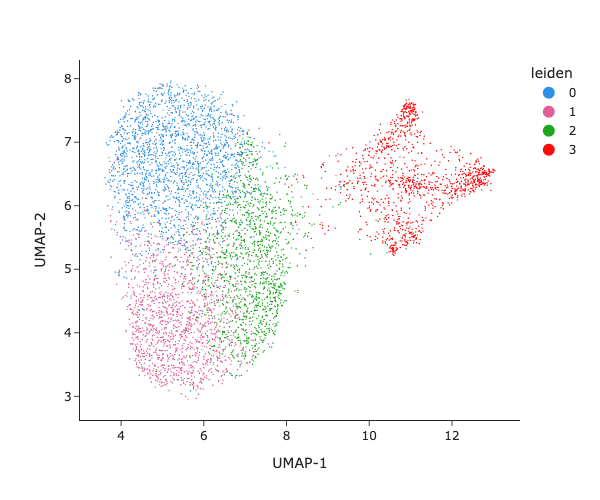

In [40]:
snap.tl.spectral(data)
snap.tl.umap(data)
snap.pp.knn(data)
snap.tl.leiden(data)
snap.pl.umap(data, color='leiden', interactive=False, height=500)

In [123]:
snap.pl.umap(data, color='leiden', interactive=False, height=500, show=False, out_file="/Users/emattei/Tmp/test_snapatac/umap_leiden.png")
snap.pl.umap(data, color='frac_dup', interactive=False, height=500, show=False,out_file="/Users/emattei/Tmp/test_snapatac/umap_frac_dup.png")
snap.pl.umap(data, color='n_fragment', interactive=False, height=500, show=False, out_file="/Users/emattei/Tmp/test_snapatac/umap_n_fragment.png")
snap.pl.umap(data, color='tsse', interactive=False, height=500, show=False, out_file="/Users/emattei/Tmp/test_snapatac/umap_tsse.png")